# OpenSubtaskTrain start/goal-state visualization

Renders, per scene, both the robot's **starting state** straight out of `reset()` (its "adjacent room" spawn position, drawer at its randomly-sampled mostly-closed starting qpos -- see "View spawn images" below) and the **goal state** the `maniskill_open_subtask_train` policy is trained toward: drawer at its *open* `target_qpos`, robot base teleported to the fixed `target_base_xy` goal point (see `env_utils._open_subtask_open_handle_positions`), facing the handle, gripper opened to the goal's `_GRIPPER_TARGET` aperture. A magenta debug sphere marks the exact `handle_pos` goal point.

Adapted from `logs/spawn_check/log_goal_examples.py` (which did the equivalent check for `maniskill_close_subtask_train`, logging to wandb) -- this notebook mirrors that script's teleport logic for the open task, but displays images inline instead of logging to wandb, since this is a one-off "does the goal look right" visual check rather than something worth a permanent wandb record.

**Missing state variables, filled in with a reasonable value for rendering** (none of these are part of the 8-dim goal vector itself -- see `env_utils.ManiskillOpenSubtaskTrain`'s docstring -- so a real rendered frame needs *something* plugged into them):
- **Heading**: goal has no heading target (mshab's own success check never depends on final base orientation) -- teleported to face the handle, purely so the screenshot reads as "parked in front of the drawer" rather than facing sideways/away.
- **Arm joint angles**: the goal only specifies `handle_pos`/`tcp` implicitly as a *target point*, never a full arm pose, so there's no single "correct" arm configuration to render. `_solve_arm_ik_fk` (see its docstring) poses the arm to approximately reach `handle_pos` anyway, purely so the screenshot reads as "reaching for the handle" rather than showing the arm folded at rest -- this is a rendering convenience, not a claim that this is *the* arm configuration the goal implies. The marker sphere remains the authoritative goal-position indicator; the arm pose is only ever an approximate visual aid (~5-7cm final error, no orientation/collision constraints).
- **Gripper finger joints**: the goal's `gripper_target` is a single scalar aperture (`_GRIPPER_TARGET=[0.10]`, fully open) -- rendering needs two per-finger joint values, so each of `l_gripper_finger_joint`/`r_gripper_finger_joint` (Fetch's max-open value, 0.05m each per `mani_skill`'s Fetch URDF limits) is set explicitly rather than left at whatever the reset pose happened to be.


**Camera**: `env_utils._ms_render_frame` (ManiSkill's default human-render camera, `render_camera`) is rigidly mounted to the robot's own `torso_lift_link` at a fixed local offset -- not a scene-fixed camera. Once teleported to `target_base_xy` facing the counter, that fixed offset often points the camera close to (or steeply down/into) the counter/wall, and -- this was the real surprise, confirmed by an independent free-standing bird's-eye camera check -- ManiSkill/ReplicaCAD scenes are a single finite furnished house floating in an otherwise empty void (no skybox/distant geometry), so a camera aimed even slightly outward near an exterior wall captures a lot of genuine black void, not a rendering bug or a missed light. Since `target_base_xy` is computed by a straight-line offset from the handle with **no room-boundary check** (deliberately -- see `_CLOSE_SUBTASK_BASE_STANDOFF_M`'s comment in env_utils.py for the tuning history behind that choice), it can end up close to the house's exterior wall for some scenes, so any camera aimed outward from there will show a lot of void no matter how it's mounted.

**Fix**: this notebook builds its own free-standing camera (`_build_overview_camera` below, via `mani_skill.sensors.camera.Camera` + `scene.add_camera(mount=None)` -- not attached to the robot), anchored at `spawn_base_xy` (guaranteed-valid -- it went through the full collision-checked spawn-generation pipeline, unlike `target_base_xy` itself) with height/FOV that scale up with the robot<->handle distance so the robot stays framed even for large `BASE_STANDOFF_M` overrides. This fixes the void problem for most scenes; a few will still show nearby furniture blocking the shot (not void) since some counters really do sit in tight corners -- that's real scene geometry, not a bug. And if `BASE_STANDOFF_M` is pushed far enough, `target_base_xy` can end up genuinely **outside the house's exterior footprint** entirely (confirmed directly: at 4.0m, one scene's goal point landed several meters into open void, well past any wall) -- in that case no camera placement can show the robot, because there's no room there to show. The printed SANITY `actual_dist` remains the reliable numeric check regardless of how the image looks.

## Setup

In [1]:
import os
import sys

REPO_ROOT = '/home/gliu2/dist_matching/sgcrl'
if REPO_ROOT not in sys.path:
  sys.path.insert(0, REPO_ROOT)

# Same env-var setup as ../maniskill_close_subtask_train/render_checkpoint_videos.ipynb's
# setup cell -- a Jupyter kernel never sees open_subtask_train.slurm's `export`
# lines, so they're set here instead, BEFORE the heavy imports below. See that
# notebook's setup cell for why each var matters (MS_ASSET_DIR/MSHAB_* for
# `_mshab_open_subtask_paths()`, PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION for the
# reverb/protobuf ABI conflict, LD_LIBRARY_PATH/CPATH/XLA_PYTHON_CLIENT_MEM_FRACTION
# for CUDA/mujoco/sapien libs dlopen'd later at first use).
os.environ.setdefault('MS_ASSET_DIR', '/data/user_data/gliu2/maniskill_data')
os.environ.setdefault('MSHAB_TASK', 'set_table')
os.environ.setdefault('MSHAB_SPLIT', 'train')
os.environ.setdefault('MSHAB_OBJ', 'kitchen_counter')
os.environ.setdefault('PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION', 'python')
os.environ.setdefault('XLA_PYTHON_CLIENT_MEM_FRACTION', '.4')
os.environ.setdefault('CPATH', '/data/user_data/gliu2/conda_envs/mshab_rl/include')

_ld_path_parts = [
    '/usr/local/cuda-11/lib64',
    '/data/user_data/gliu2/conda_envs/mshab_rl/lib',
    '/home/gliu2/.mujoco/mujoco210/bin',
    '/usr/lib/nvidia',
]
try:
  # Torch's own bundled (correct) libcusolver must come first -- same fix as
  # open_subtask_train.slurm's matching comment.
  import nvidia.cusolver as _cusolver
  _ld_path_parts.insert(
      0, os.path.join(os.path.dirname(_cusolver.__file__), 'lib'))
except ImportError:
  pass
os.environ['LD_LIBRARY_PATH'] = os.pathsep.join(
    _ld_path_parts + [os.environ.get('LD_LIBRARY_PATH', '')]).rstrip(os.pathsep)

import sgcrl_jax_acme_compat  # noqa: F401 -- must precede all acme/jax imports

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from mani_skill.utils.building import actors as ms_actors
from mani_skill.utils import sapien_utils
from mani_skill.sensors.camera import Camera as _MsCamera, CameraConfig as _MsCameraConfig

import env_utils

/data/user_data/gliu2/conda_envs/mshab_rl/lib/python3.9/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/data/user_data/gliu2/conda_envs/mshab_rl/lib/python3.9/site-packages/sapien/_vulkan_tricks.py:37: UserWarning: Failed to find Vulkan ICD file. This is probably due to an incorrect or partial installation of the NVIDIA driver. SAPIEN will attempt to provide an ICD file anyway but it may not work.
  warn(


/data/user_data/gliu2/conda_envs/mshab_rl/lib/python3.9/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


## Config

As of the goal-vector-flip + spawn-restriction fix (see `env_utils._OPEN_SUBTASK_EASY_SCENE`
and its docstring comment), `maniskill_open_subtask_train` no longer trains across all 63
ReplicaCAD scenes -- it's restricted to the single scene mshab deterministically assigns to
env slot 0 (`v3_sc0_staging_00.scene_instance.json`, the same room every close-subtask
checkpoint video has ever shown, including the specific success the user identified: training
run seed 9, "Find successful rollouts" attempt 0). This notebook applies that exact same
restriction (`env_utils._filter_open_subtask_plan_data`) before picking `PLAN_INDICES`, so
what's rendered below is a **visual check of what training actually sees now**, not a
cross-section of the old, unrestricted 63-scene distribution -- every example should show the
same room, and each example's spawn position should read as reachable/unblocked, since the
open task plan's spawn data for this scene is a verbatim copy of close's own already-validated
`robot_pos`/`robot_qpos` (see `scripts/build_open_spawn_data.py`; same uid, same close-subtask
spawn point).

**Second restriction**: even within that one scene, the 145 task-plan entries' spawn points
fall into two well-separated clusters -- one near the two armchairs by the room's inner doorway,
one near the sofa/coffee-table/staircase side closer to an exterior wall (visible as two
distinct framings in an earlier version of this notebook's spawn-image grid). The user asked to
keep only the near-armchairs cluster, so `_filter_open_subtask_plan_data` now also filters on
`robot_pos` x (`env_utils._OPEN_SUBTASK_EASY_SPAWN_MAX_X`), leaving 69 of the 145 entries. Every
spawn image below should now show the armchairs, not the staircase/sofa framing.

`PLAN_INDICES` now spans the **filtered** (69-entry) plan list to land on different drawer
instances/spawn-qpos samples *within* that one cluster, not different scenes or clusters. Kept
to 3 representative indices (rather than the earlier 6) since the standoff comparison below
renders each one 3x (see next paragraph) -- this keeps total render count (3 plans x 3
standoffs = 9) comparable to the older single-standoff 6-plan grid.

**Base-standoff comparison (0.5m / 1.0m / 1.5m).** Currently `_OPEN_SUBTASK_BASE_STANDOFF_M
=0.5` while `_CLOSE_SUBTASK_BASE_STANDOFF_M=1.0` -- the user flagged that this is backwards:
the robot should park *at least as far* from the handle when the drawer ends up open (and thus
physically occupies more of the space in front of the counter) as when it ends up closed, not
closer. Close's own 1.0m standoff also has a validated safety margin behind it (a real physics
collision sweep found 0.35m as the bare collision-free minimum for this furniture -- see
`_CLOSE_SUBTASK_BASE_STANDOFF_M`'s comment in `env_utils.py`); open's 0.5m leaves only ~0.15m
of margin above that same floor.

`BASE_STANDOFF_VALUES` below renders the same handful of plan indices at all three candidate
distances (0.5, 1.0, 1.5m) side by side, so the standoff choice can be made visually instead of
by guessing. **The gripper's own goal target does NOT move with the standoff** -- `handle_pos`
(the goal's tcp target, first 3 dims of the 8-dim goal vector) is always `open_p` offset by the
fixed, small `GRIPPER_APPROACH_OFFSET_M` (0.05m) along the handle's local motion axis,
completely independent of `BASE_STANDOFF_M`/`base_target_xy` (see
`_open_handle_positions_custom` below -- `gripper_offset_m` and `base_standoff_m` are two
separate parameters applied to the same `open_p`/`unit_axis`). Only the *base's* parking point
moves; the arm has to reach further from wherever the base ends up to still land the gripper at
that same fixed point near the handle (see `_solve_arm_ik_fk`, called fresh per standoff value
below with the same `open_handle_world_p` target every time -- this is the rendering-side
realization of "the gripper position adjusts accordingly": not a change to the goal vector's
`handle_pos` value, but the rendered arm pose stretching further to still reach it). The
per-example `arm IK final error` printout is the empirical check for whether that's still
physically feasible -- a small error (like the ~0-5cm typical at 0.5m) means the arm can
comfortably reach; if it grows noticeably at 1.5m, that's a sign the Fetch arm's reach is being
exceeded from that far back, which would itself argue against pushing the standoff that high.

This override is a **render-only** local copy of the FK-peek math (`_open_handle_positions_custom`
below), parameterized instead of using the hardcoded `env_utils._OPEN_SUBTASK_BASE_STANDOFF_M`;
it does NOT change what training actually targets -- `env_utils.py` itself is untouched by this
notebook. Once a value is picked from the comparison, it still needs to be applied to
`env_utils._OPEN_SUBTASK_BASE_STANDOFF_M` by hand for training to pick it up.

Note on large overrides: the overview camera's heuristic (see `_build_overview_camera`) stays
mostly anchored near the collision-checked spawn point rather than fully tracking
`base_target_xy`, so pushing the standoff well past ~1.5-2m can push the robot out of the
camera's practical range (occluded or just too far/off-axis) well before it leaves the house
entirely -- confirmed at 2.0m for one scene in earlier exploration. At 4.0m, `base_target_xy`
itself lands several meters into open void, outside the house's exterior footprint. The three
values compared here (0.5/1.0/1.5m) all stay well inside that safe range.

In [2]:
PLAN_INDICES = [0, 30, 60]
BASE_STANDOFF_VALUES = [0.5, 0.7, 1.0, 1.5]

# Render-only override -- see the Config markdown cell above. The gripper
# approach offset is NOT part of this comparison (it stays fixed/small
# regardless of base standoff -- see the markdown cell for why); only the
# base standoff is swept.
GRIPPER_APPROACH_OFFSET_M = env_utils._CLOSE_SUBTASK_APPROACH_OFFSET_M  # 0.05

task_plan_fp, spawn_data_fp = env_utils._mshab_open_subtask_paths()
plan_data = env_utils._mshab_plan_data_from_file(task_plan_fp)
print(f'[render_goal_state] {len(plan_data.plans)} task-plan entries total (unfiltered)')

# Same restriction ManiskillOpenSubtaskTrain.__init__ applies to real training
# now (see env_utils._OPEN_SUBTASK_EASY_SCENE /
# env_utils._OPEN_SUBTASK_EASY_SPAWN_MAX_X) -- without this, PLAN_INDICES
# below would sample from the old, unrestricted 63-scene/both-clusters
# distribution instead of what training actually sees.
plan_data = env_utils._filter_open_subtask_plan_data(plan_data)
print(f'[render_goal_state] {len(plan_data.plans)} task-plan entries after '
      f'restricting to _OPEN_SUBTASK_EASY_SCENE='
      f'{env_utils._OPEN_SUBTASK_EASY_SCENE!r} and the near-armchairs spawn '
      f'cluster (robot_pos x < {env_utils._OPEN_SUBTASK_EASY_SPAWN_MAX_X})')
print(f'[render_goal_state] task_plan_fp={task_plan_fp}')
print(f'[render_goal_state] spawn_data_fp={spawn_data_fp}')
print(f'[render_goal_state] GRIPPER_APPROACH_OFFSET_M={GRIPPER_APPROACH_OFFSET_M} '
      f'BASE_STANDOFF_VALUES={BASE_STANDOFF_VALUES} '
      f'(trained default is env_utils._OPEN_SUBTASK_BASE_STANDOFF_M='
      f'{env_utils._OPEN_SUBTASK_BASE_STANDOFF_M}; close uses '
      f'env_utils._CLOSE_SUBTASK_BASE_STANDOFF_M='
      f'{env_utils._CLOSE_SUBTASK_BASE_STANDOFF_M} for comparison)')

[render_goal_state] 10000 task-plan entries total (unfiltered)


[render_goal_state] 69 task-plan entries after restricting to _OPEN_SUBTASK_EASY_SCENE='v3_sc0_staging_00.scene_instance.json' and the near-armchairs spawn cluster (robot_pos x < 1.5)
[render_goal_state] task_plan_fp=/data/user_data/gliu2/maniskill_data/data/scene_datasets/replica_cad_dataset/rearrange/task_plans/set_table/open/train/kitchen_counter.json
[render_goal_state] spawn_data_fp=/data/user_data/gliu2/maniskill_data/data/scene_datasets/replica_cad_dataset/rearrange/spawn_data/set_table/open/train/spawn_data.pt
[render_goal_state] GRIPPER_APPROACH_OFFSET_M=0.05 BASE_STANDOFF_VALUES=[0.5, 0.7, 1.0, 1.5] (trained default is env_utils._OPEN_SUBTASK_BASE_STANDOFF_M=0.5; close uses env_utils._CLOSE_SUBTASK_BASE_STANDOFF_M=1.0 for comparison)


## Render goal-state images

For each (now scene-restricted, see Config above) task-plan entry: build **one** fresh
single-env instance (mirroring `log_goal_examples.py`'s approach -- with `num_envs=1` and
`reconfiguration_freq=0` a single env would otherwise always land on the same scene across
resets, so a fresh env per `plan_idx` with a different single-entry `task_plans=[...]` slice is
used instead), `reset()` it, capture its spawn image once, then **loop over
`BASE_STANDOFF_VALUES`** re-teleporting the same env into each candidate goal configuration in
turn (drawer/robot/gripper/arm) and rendering one frame per standoff -- no need to rebuild the
env for each standoff value since only kinematic `set_qpos`/`set_pose` calls change between
them. A single reusable debug marker (moved via `set_pose`, not rebuilt) marks the goal's
`handle_pos` in every frame -- this stays in the exact same world position across all three
standoffs for a given `plan_idx`, since (see Config above) the gripper's target offset is
independent of the base standoff being swept.

For each `(plan_idx, standoff)` pair, computes `handle_pos`/`target_base_xy` via a local copy of
the FK-peek helper training uses (`_open_handle_positions_custom` below -- same math as
`env_utils._open_subtask_open_handle_positions`, just parameterized by
`GRIPPER_APPROACH_OFFSET_M`/`base_standoff_m` instead of the hardcoded constants), teleports into
that goal configuration, solves approximate arm IK toward the (standoff-independent)
`handle_pos` target, and renders one frame from a free-standing `_build_overview_camera` (see the
intro markdown cell for why -- the robot-mounted `render_camera` frequently shows mostly black
void for this scene family).

Also prints, per `(plan_idx, standoff)`, the **literal** handle position at the open
`target_qpos` (no approach offset) next to the **goal's** `handle_pos` (offset back toward
closed by `GRIPPER_APPROACH_OFFSET_M`) -- see the markdown cell below the images for what this
offset means -- and the arm IK final error, the empirical "can the arm actually still reach the
handle from here" check for each standoff.

This is a visualization-only teleport -- each `plan_idx` gets its own fresh env that's closed
right after its 3 standoff renders, so there's nothing to restore afterward.

In [3]:
def _frame(raw):
  frame = raw.detach().cpu().numpy() if hasattr(raw, 'detach') else raw
  frame = np.asarray(frame)
  if frame.ndim == 4:
    frame = frame[0]
  return np.ascontiguousarray(frame).astype(np.uint8)


def _build_overview_camera(unwrapped, spawn_xy, base_target_xy, handle_p,
                           width=960, height=720, side=1.0):
  """Free-standing (not robot-mounted) camera for the goal-state screenshot.

  See the intro markdown cell for why this exists: `env_utils._ms_render_frame`
  uses ManiSkill's `render_camera`, which is rigidly mounted to the robot's
  torso -- once teleported to face the counter, that fixed offset often
  looks straight into a wall/void. `scene.add_camera(mount=None)` instead
  places a camera at a literal world pose, independent of the robot.

  v3: frames the DRAWER, not the robot -- fixes v2's actual failure mode.
  v2 (side-on, near-handle-height) fixed the "bird's-eye tabletop fills the
  frame" problem but introduced a new one: `target` blended 50/50 toward
  `base_target_xy` (where the robot parks), and at small standoffs (e.g.
  0.5m) the robot stands right next to the handle, so aiming partway
  toward it put the robot's own torso directly in the foreground,
  dominating the shot and hiding the counter/drawer behind it -- visible
  in v2's images as an extreme close-up of the Fetch torso instead of the
  cabinet. v3 removes that bias entirely: `eye`/`target` are both anchored
  purely on `handle_p` (the drawer), with a pure perpendicular lateral
  offset (no lean toward the robot's side) and a larger `lateral_dist`
  floor, so the shot centers the drawer's protruding front face
  side-on/three-quarter regardless of where the robot ends up. The robot
  may still appear at the frame's edge (informative context), but the
  drawer itself -- not the robot -- is now what's centered and in focus.

  `side` (default +1.0, flip to -1.0 for the opposite lateral side):
  which of the two directions perpendicular to the slide axis to place the
  camera on. Added when the close-subtask comparison render (further
  below) came out with the default `+1.0` side clipped by nearby room
  geometry (a wall/doorway corner close to the *closed*-position handle
  point that isn't in the way of the *open*-position handle point a few
  tens of cm further along the same axis) -- the open-subtask renders
  above all look fine at the default side, so this is a per-call escape
  hatch rather than a change to their behavior.

  Placement, adaptive on `span = |base_target_xy - handle_xy|` (the
  standoff distance being visualized, used only to scale distance/FOV, not
  to steer the camera toward the robot):
  - `perp_dir`: unit vector perpendicular (in-plane) to the
    handle->base_target approach direction (i.e. perpendicular to the
    drawer's own prismatic slide axis) -- viewing across the slide axis is
    what makes an open drawer's protrusion read as a visible step/gap
    against the flush cabinet next to it, rather than receding straight
    away from the camera (which a head-on view down the slide axis would
    do, hiding the protrusion depth entirely).
  - `eye = handle_xy + perp_dir * lateral_dist`, `lateral_dist =
    clip(1.5 + 0.2*span, 1.5, 2.2)` -- a fixed, generous lateral offset
    from the drawer itself, independent of the robot's position.
  - `eye_z = clip(handle_z + 0.5, 1.0, 1.6)`: modest height above the
    handle -- enough to see over the counter's own depth without looking
    steeply down at the tabletop (v1's problem).
  - `target = handle_p` itself (not blended toward the robot) -- keeps the
    drawer centered and in focus.

  Degenerate-span fallback (`base_target_xy` == `handle_xy`, e.g. an
  already-fully-open joint with no valid axis): `approach_dir` (used only
  to derive `perp_dir`) defaults to world +x rather than dividing by zero.
  """
  handle_xy = handle_p[:2]
  handle_z = float(handle_p[2])
  approach = base_target_xy - handle_xy
  span = float(np.linalg.norm(approach))
  approach_dir = approach / span if span > 1e-6 else np.array([1.0, 0.0])
  perp_dir = np.array([-approach_dir[1], approach_dir[0]]) * side

  lateral_dist = float(np.clip(1.5 + 0.2 * span, 1.5, 2.2))
  eye_xy = handle_xy + perp_dir * lateral_dist
  eye_z = float(np.clip(handle_z + 0.5, 1.0, 1.6))
  fov_deg = float(np.clip(55 + 3 * span, 55, 80))

  eye = [float(eye_xy[0]), float(eye_xy[1]), eye_z]
  target = [float(handle_xy[0]), float(handle_xy[1]), handle_z]
  cam_pose = sapien_utils.look_at(eye, target)
  cam_cfg = _MsCameraConfig('overview_camera', cam_pose, width, height,
                            np.deg2rad(fov_deg), 0.01, 25)
  return _MsCamera(cam_cfg, unwrapped.scene)


def _open_handle_positions_custom(unwrapped, env_idx, gripper_offset_m, base_standoff_m):
  """Same math as `env_utils._open_subtask_open_handle_positions`, but with
  configurable offsets instead of the hardcoded training constants -- lets
  this notebook explore standoff distances without touching env_utils.py
  (i.e. without changing what training itself targets). Returns
  `(handle_target_p, base_target_xy, literal_open_p)`, the last being the
  *unoffset* handle position at target_qpos -- for comparing against
  handle_target_p (see the markdown cell after the images).

  `handle_target_p` depends only on `gripper_offset_m`, NOT `base_standoff_m`
  -- both offsets are applied independently to the same `open_p`/`unit_axis`
  anchor, so sweeping `base_standoff_m` (as the render loop below does)
  never moves the gripper's own goal target; only `base_target_xy` moves.

  Probes toward qmax (more open), matching env_utils.py's fixed direction
  bug (see that function's docstring): an earlier version of this notebook
  (and of env_utils.py itself) probed toward qmin instead, reasoning by
  qpos-space symmetry with close's own offset -- wrong, because "away from
  the cabinet, into the room" is always the +qpos direction for a prismatic
  drawer, regardless of which qpos value the FK-peek is anchored at. That
  bug was caught by visual inspection of this notebook's own rendered
  images: the robot's base landed behind/inside the counter, facing away
  from the handle, instead of parked in front of it.
  """
  articulation = unwrapped.articulation
  joint_idx = unwrapped.open_subtask.articulation_handle_active_joint_idx
  gpu_sim = unwrapped.gpu_sim_enabled
  env_idx_np = env_idx.detach().cpu().numpy()

  orig_qpos = articulation.qpos.clone()

  def _handle_pos_at(qpos_values):
    peek_qpos = orig_qpos.clone()
    peek_qpos[env_idx, joint_idx] = qpos_values
    articulation.set_qpos(peek_qpos)
    if gpu_sim:
      unwrapped.scene._gpu_apply_all()
      unwrapped.scene.px.gpu_update_articulation_kinematics()
      unwrapped.scene._gpu_fetch_all()
    pose = (unwrapped.link.pose
            * unwrapped.open_subtask.articulation_relative_handle_pos)
    return env_utils._ms_to_numpy_batched(pose.p)[env_idx_np]

  target_qpos = unwrapped.target_qpos[env_idx]
  qmax = unwrapped.qmax[env_idx]
  qmin = unwrapped.qmin[env_idx]
  probe_qpos = torch.minimum(target_qpos + 0.05 * (qmax - qmin), qmax)

  open_p = _handle_pos_at(target_qpos)
  probe_p = _handle_pos_at(probe_qpos)

  articulation.set_qpos(orig_qpos)
  if gpu_sim:
    unwrapped.scene._gpu_apply_all()
    unwrapped.scene.px.gpu_update_articulation_kinematics()
    unwrapped.scene._gpu_fetch_all()

  axis_dir = probe_p - open_p
  axis_norm = np.linalg.norm(axis_dir, axis=1, keepdims=True)
  degenerate = axis_norm < 1e-6  # e.g. already at qmax
  safe_norm = np.where(degenerate, 1.0, axis_norm)
  unit_axis = axis_dir / safe_norm
  gripper_offset = np.where(degenerate, 0.0, gripper_offset_m)
  handle_target_p = open_p + gripper_offset * unit_axis
  base_offset = np.where(degenerate, 0.0, base_standoff_m)
  base_target_xy = (open_p + base_offset * unit_axis)[:, :2]
  return handle_target_p, base_target_xy, open_p


# Fetch's arm joints, in `agent.robot.get_qpos()`'s index order (see the
# gripper-finger-index note below for how this ordering was confirmed:
# `agent.robot.get_active_joints()` -- NOT `obs_dict['agent']['qpos']`'s
# shorter, base-excluded ordering).
_FETCH_ARM_QPOS_INDICES = [5, 7, 8, 9, 10, 11, 12]


def _solve_arm_ik_fk(unwrapped, base_qpos, target_p, maxiter=300):
  """Approximate arm IK for rendering: pose the arm so the gripper (tcp)
  ends up near `target_p`, purely so the goal-state screenshot shows the
  arm reaching toward the handle instead of sitting in its folded rest
  pose (which is what's left after `reset()` if this is skipped -- see the
  intro markdown cell's note on why the arm pose isn't otherwise touched:
  it isn't part of the goal vector).

  Also doubles, in this notebook's standoff comparison, as the practical
  "can the arm even reach that far" check: `target_p` (the goal's
  `handle_pos`) never changes across standoff values (see
  `_open_handle_positions_custom`'s docstring), but `base_qpos` does, so
  re-solving this per standoff with the base at each candidate distance and
  watching the returned error grow is the empirical signal for whether a
  given standoff is still within arm reach from that base position.

  `mani_skill.agents.controllers.utils.kinematics.Kinematics.compute_ik`
  (the "real" IK entry point mani_skill ships, used by its `pd_ee_pose`
  controllers) was tried first and rejected -- on this pinned mani_skill
  version, its CPU/pinocchio path (`num_envs=1` uses CPU sim here) fails
  even on trivial cases (e.g. solving IK back to the arm's OWN current
  pose returns `None`), so it isn't a reliable foundation to build on.
  Instead, this does a direct black-box optimization against ManiSkill's
  own forward kinematics (`agent.tcp.pose`, which we already know is
  reliable -- it's what every other FK-peek in this notebook/env_utils.py
  reads from): `scipy.optimize.minimize` (Nelder-Mead, bounded by each
  joint's own qlimits) searching over just the 7 arm joint angles for
  whichever configuration puts `agent.tcp.pose.p` closest to `target_p`,
  seeded from the arm's current (rest) qpos. Empirically converges to
  within ~5-7cm of the target in a few hundred FK evaluations (a fraction
  of a second, single env, CPU) when the target is in reach -- good enough
  to visually read as "reaching for the handle," not intended as an
  exact/general-purpose solver (no collision avoidance, no orientation
  constraint); when the target is OUT of reach the optimizer still
  converges, just to a larger residual error, which is exactly the signal
  this notebook wants at large standoffs.
  """
  robot = unwrapped.agent.robot
  qlimits = robot.get_qlimits()[0]
  bounds = [(float(qlimits[i, 0]) if np.isfinite(qlimits[i, 0]) else None,
             float(qlimits[i, 1]) if np.isfinite(qlimits[i, 1]) else None)
            for i in _FETCH_ARM_QPOS_INDICES]
  target = np.asarray(target_p, dtype=np.float64)

  def _fk_sqdist(x):
    q = base_qpos.clone()
    for k, idx in enumerate(_FETCH_ARM_QPOS_INDICES):
      q[:, idx] = float(x[k])
    robot.set_qpos(q)
    p = unwrapped.agent.tcp.pose.p[0].detach().cpu().numpy().astype(np.float64)
    return float(np.sum((p - target) ** 2))

  x0 = np.array([float(base_qpos[0, idx]) for idx in _FETCH_ARM_QPOS_INDICES])
  result = minimize(_fk_sqdist, x0, method='Nelder-Mead', bounds=bounds,
                    options=dict(maxiter=maxiter, xatol=1e-4, fatol=1e-6))
  solved_qpos = base_qpos.clone()
  for k, idx in enumerate(_FETCH_ARM_QPOS_INDICES):
    solved_qpos[:, idx] = float(result.x[k])
  return solved_qpos, float(np.sqrt(result.fun))


# Fetch's per-finger max-open joint value (mani_skill/agents/robots/fetch/fetch.py) --
# _GRIPPER_TARGET=[0.10] is the *sum* of both fingers, so each finger gets half.
_FETCH_FINGER_MAX_OPEN_M = 0.05

spawn_images = []
# Row-major by standoff, column-major by plan_idx: goal_images_grid[j][i] /
# captions_grid[j][i] correspond to (BASE_STANDOFF_VALUES[j], PLAN_INDICES[i]).
goal_images_grid = [[None] * len(PLAN_INDICES) for _ in BASE_STANDOFF_VALUES]
captions_grid = [[None] * len(PLAN_INDICES) for _ in BASE_STANDOFF_VALUES]

for i, plan_idx in enumerate(PLAN_INDICES):
  plan = plan_data.plans[plan_idx]
  gym_raw = env_utils._gymnasium.make(
      'OpenSubtaskTrain-v0',
      obs_mode='state_dict',
      control_mode='pd_joint_delta_pos',
      reward_mode='normalized_dense',
      render_mode='rgb_array',
      robot_uids='fetch',
      num_envs=1,
      task_plans=[plan],
      scene_builder_cls=plan_data.dataset,
      spawn_data_fp=spawn_data_fp,
      require_build_configs_repeated_equally_across_envs=False,
      sim_config=dict(
          gpu_memory_config=dict(
              temp_buffer_capacity=2**25,
              max_rigid_contact_count=2**24,
              found_lost_pairs_capacity=2**26,
              max_rigid_patch_count=2**22)))
  obs_dict, _info = gym_raw.reset()
  unwrapped = gym_raw.unwrapped
  # Captured now (pre-teleport) -- this is the real, collision-checked
  # spawn position, used as an anchor for the overview camera below AND
  # to render the spawn-state image itself (see 'View spawn images'
  # below). Uses the default robot-mounted render_camera, not the
  # free-standing overview camera the goal-state shots need -- the void
  # problem that motivated building that camera is specific to the
  # goal-state teleport (which deliberately parks the robot right next
  # to the counter/wall); at its own validated spawn pose the robot
  # isn't artificially placed near an exterior wall, so the plain
  # default camera works fine here (same as log_goal_examples.py's own
  # spawn shots for the close-subtask task). Captured once per plan_idx,
  # not once per standoff -- spawn is independent of the standoff sweep.
  spawn_images.append(_frame(env_utils._ms_render_frame(gym_raw)))
  spawn_base_xy = env_utils._ms_to_numpy(unwrapped.agent.base_link.pose.p)[:2]
  joint_idx = unwrapped.open_subtask.articulation_handle_active_joint_idx
  env_idx = torch.zeros(1, dtype=torch.long, device=unwrapped.device)

  # One reusable debug marker per plan_idx, moved (not rebuilt) for each
  # standoff -- avoids leaving stale spheres from earlier standoffs visible
  # in later renders on the same env. Initial pose is a placeholder;
  # repositioned to the real handle_pos before the first render below.
  debug_marker = ms_actors.build_sphere(
      unwrapped.scene, radius=0.1, color=[1, 0, 1, 1],
      name=f'debug_handle_marker_{i}', body_type='kinematic',
      add_collision=False,
      initial_pose=env_utils._MsPose.create_from_pq(
          p=torch.zeros((1, 3), dtype=torch.float32)))

  for j, standoff_m in enumerate(BASE_STANDOFF_VALUES):
    handle_target_p, base_target_xy, literal_open_p = _open_handle_positions_custom(
        unwrapped, env_idx, GRIPPER_APPROACH_OFFSET_M, standoff_m)
    open_handle_world_p = handle_target_p[0]
    literal_open_p = literal_open_p[0]
    base_target_xy = base_target_xy[0]

    # World-frame base position -- NOT `agent.robot.get_qpos()[:2]`, which is
    # relative to a per-scene root anchor pose, not world origin (see
    # env_utils.py's `_get_obs` comment / log_goal_examples.py's matching note
    # for the empirical measurement that caught this).
    root_xy = env_utils._ms_to_numpy(unwrapped.agent.robot.root_pose.p)[:2]
    handle_dist = float(np.linalg.norm(base_target_xy - open_handle_world_p[:2]))
    gripper_vs_literal = float(np.linalg.norm(open_handle_world_p - literal_open_p))
    print(f'[render_goal_state] plan_idx={plan_idx} standoff={standoff_m}m '
          f'scene={plan.build_config_name} target_base_xy={base_target_xy} '
          f'target_to_handle={handle_dist:.2f}m')
    print(f'[render_goal_state] plan_idx={plan_idx} standoff={standoff_m}m '
          f'GRIPPER TARGET vs literal open-handle pos: '
          f'goal handle_pos(world)={open_handle_world_p}  '
          f'literal handle @ target_qpos(world)={literal_open_p}  '
          f'offset_dist={gripper_vs_literal:.3f}m')

    # --- Teleport into the goal configuration ---
    # 1. Drawer joint -> open target_qpos. (Independent of standoff --
    #    redone each iteration for simplicity, harmless since it's the same
    #    value every time.)
    orig_art_qpos = unwrapped.articulation.qpos.clone()
    peek_art_qpos = orig_art_qpos.clone()
    peek_art_qpos[:, joint_idx] = unwrapped.target_qpos
    unwrapped.articulation.set_qpos(peek_art_qpos)

    # 2. Robot base -> target_base_xy (THIS standoff's value), facing the
    #    handle (heading is a rendering choice only, see the intro markdown
    #    cell -- not part of the goal vector, never fed to the policy).
    peek_robot_qpos = unwrapped.agent.robot.get_qpos().clone()
    handle_xy = open_handle_world_p[:2]
    facing = float(np.arctan2(handle_xy[1] - base_target_xy[1],
                              handle_xy[0] - base_target_xy[0]))
    # world -> root-relative qpos delta (see root_xy's comment above) -- NOT
    # writing base_target_xy (world frame) directly into qpos[0:2].
    qpos_xy = base_target_xy - root_xy
    peek_robot_qpos[:, 0] = float(qpos_xy[0])
    peek_robot_qpos[:, 1] = float(qpos_xy[1])
    peek_robot_qpos[:, 2] = facing
    # 3. Gripper fingers -> goal's gripper_target aperture (fully open), split
    #    evenly across both fingers -- see intro markdown for why this needs to
    #    be filled in explicitly rather than left at the reset pose.
    #    NOTE: indices 13/14, NOT 10/11 -- `agent.robot.get_qpos()` is the
    #    RAW 15-dof articulation vector (base included at indices 0-2, then
    #    torso/head/arm, then r/l_gripper_finger_joint LAST at 13/14 -- see
    #    `unwrapped.agent.robot.get_active_joints()`'s name order). This is a
    #    DIFFERENT ordering from `obs_dict['agent']['qpos']` (env_utils.py's
    #    `_get_obs` reads gripper_aperture off THAT array's indices 10/11 --
    #    correct there, since that array excludes the base entirely, shifting
    #    everything down by 3). Using 10/11 here instead clobbered
    #    forearm_roll_joint/wrist_flex_joint (arm joints, not fingers) --
    #    wrist_flex's natural rest value (~1.83 rad) got force-set to 0.05,
    #    straightening the wrist and making the arm look stretched toward the
    #    counter instead of folded at its post-reset (near-rest) pose.
    peek_robot_qpos[:, 13] = _FETCH_FINGER_MAX_OPEN_M
    peek_robot_qpos[:, 14] = _FETCH_FINGER_MAX_OPEN_M
    unwrapped.agent.robot.set_qpos(peek_robot_qpos)

    # 4. Arm -> approximate IK toward the goal's handle_pos (see
    #    _solve_arm_ik_fk's docstring -- rendering-only, not part of the
    #    goal vector, doesn't touch env_utils.py/training). Same
    #    open_handle_world_p target at every standoff -- growing error here
    #    across standoffs is the "arm can't reach that far" signal.
    solved_qpos, ik_err_m = _solve_arm_ik_fk(
        unwrapped, peek_robot_qpos, open_handle_world_p)
    unwrapped.agent.robot.set_qpos(solved_qpos)
    print(f'[render_goal_state] plan_idx={plan_idx} standoff={standoff_m}m '
          f'arm IK final error: {ik_err_m:.3f}m')

    # Move the reusable marker to this standoff's (standoff-independent)
    # handle_pos goal point -- mshab's own goal markers are forced invisible
    # in human render (see log_goal_examples.py's matching comment for the
    # empirical finding that motivated this), so this bypasses that path.
    debug_marker.set_pose(env_utils._MsPose.create_from_pq(
        p=torch.as_tensor(open_handle_world_p[None], dtype=torch.float32)))

    if unwrapped.gpu_sim_enabled:
      unwrapped.scene._gpu_apply_all()
      unwrapped.scene.px.gpu_update_articulation_kinematics()
      unwrapped.scene._gpu_fetch_all()

    # Sanity check: read back the *actual* post-set world state, not the
    # upstream variables, to rule out a mismatch between intended and actual.
    actual_base_xy = env_utils._ms_to_numpy(unwrapped.agent.base_link.pose.p)[:2]
    actual_marker_xy = env_utils._ms_to_numpy(debug_marker.pose.p)[:2]
    print(f'[render_goal_state] plan_idx={plan_idx} standoff={standoff_m}m '
          f'SANITY: intended base_target_xy={base_target_xy}, actual robot '
          f'base_xy={actual_base_xy}; intended marker_xy={open_handle_world_p[:2]}, '
          f'actual marker_xy={actual_marker_xy}; '
          f'actual_dist={np.linalg.norm(actual_base_xy - actual_marker_xy):.2f}m')

    overview_cam = _build_overview_camera(
        unwrapped, spawn_base_xy, base_target_xy, open_handle_world_p)
    unwrapped.scene.update_render()
    overview_cam.capture()
    overview_rgb = overview_cam.get_obs(
        rgb=True, depth=False, position=False, segmentation=False)['rgb']
    goal_images_grid[j][i] = _frame(overview_rgb)
    captions_grid[j][i] = (
        f'plan_idx={plan_idx} standoff={standoff_m}m\n'
        f'{plan.build_config_name}\n'
        f'target_base_xy={base_target_xy}\n'
        f'target_to_handle={handle_dist:.2f}m  ik_err={ik_err_m:.3f}m')
    print(f'[render_goal_state] captured plan_idx={plan_idx} standoff={standoff_m}m\n')

  gym_raw.close()

print('Done.')

[render_goal_state] plan_idx=0 standoff=0.5m scene=v3_sc0_staging_00.scene_instance.json target_base_xy=[ 1.77171767 -5.36789227] target_to_handle=0.45m
[render_goal_state] plan_idx=0 standoff=0.5m GRIPPER TARGET vs literal open-handle pos: goal handle_pos(world)=[ 1.32171767 -5.36789227  0.54939991]  literal handle @ target_qpos(world)=[ 1.2717177 -5.3678923  0.5493999]  offset_dist=0.050m
[render_goal_state] plan_idx=0 standoff=0.5m arm IK final error: 0.000m
[render_goal_state] plan_idx=0 standoff=0.5m SANITY: intended base_target_xy=[ 1.77171767 -5.36789227], actual robot base_xy=[ 1.7717175 -5.3678923]; intended marker_xy=[ 1.32171767 -5.36789227], actual marker_xy=[ 1.3217176 -5.3678923]; actual_dist=0.45m
[render_goal_state] captured plan_idx=0 standoff=0.5m

[render_goal_state] plan_idx=0 standoff=0.7m scene=v3_sc0_staging_00.scene_instance.json target_base_xy=[ 1.97171767 -5.36789227] target_to_handle=0.65m
[render_goal_state] plan_idx=0 standoff=0.7m GRIPPER TARGET vs literal

[render_goal_state] captured plan_idx=0 standoff=0.7m

[render_goal_state] plan_idx=0 standoff=1.0m scene=v3_sc0_staging_00.scene_instance.json target_base_xy=[ 2.27171767 -5.36789227] target_to_handle=0.95m
[render_goal_state] plan_idx=0 standoff=1.0m GRIPPER TARGET vs literal open-handle pos: goal handle_pos(world)=[ 1.32171767 -5.36789227  0.54939991]  literal handle @ target_qpos(world)=[ 1.2717177 -5.3678923  0.5493999]  offset_dist=0.050m
[render_goal_state] plan_idx=0 standoff=1.0m arm IK final error: 0.047m
[render_goal_state] plan_idx=0 standoff=1.0m SANITY: intended base_target_xy=[ 2.27171767 -5.36789227], actual robot base_xy=[ 2.2717175 -5.3678923]; intended marker_xy=[ 1.32171767 -5.36789227], actual marker_xy=[ 1.3217176 -5.3678923]; actual_dist=0.95m
[render_goal_state] captured plan_idx=0 standoff=1.0m

[render_goal_state] plan_idx=0 standoff=1.5m scene=v3_sc0_staging_00.scene_instance.json target_base_xy=[ 2.77171767 -5.36789227] target_to_handle=1.45m
[render_goal_st

[render_goal_state] plan_idx=30 standoff=0.5m scene=v3_sc0_staging_00.scene_instance.json target_base_xy=[ 1.77171767 -5.36789227] target_to_handle=0.45m
[render_goal_state] plan_idx=30 standoff=0.5m GRIPPER TARGET vs literal open-handle pos: goal handle_pos(world)=[ 1.32171767 -5.36789227  0.54939991]  literal handle @ target_qpos(world)=[ 1.2717177 -5.3678923  0.5493999]  offset_dist=0.050m
[render_goal_state] plan_idx=30 standoff=0.5m arm IK final error: 0.000m
[render_goal_state] plan_idx=30 standoff=0.5m SANITY: intended base_target_xy=[ 1.77171767 -5.36789227], actual robot base_xy=[ 1.7717177 -5.3678923]; intended marker_xy=[ 1.32171767 -5.36789227], actual marker_xy=[ 1.3217176 -5.3678923]; actual_dist=0.45m
[render_goal_state] captured plan_idx=30 standoff=0.5m

[render_goal_state] plan_idx=30 standoff=0.7m scene=v3_sc0_staging_00.scene_instance.json target_base_xy=[ 1.97171767 -5.36789227] target_to_handle=0.65m
[render_goal_state] plan_idx=30 standoff=0.7m GRIPPER TARGET vs 

[render_goal_state] plan_idx=30 standoff=1.0m arm IK final error: 0.048m
[render_goal_state] plan_idx=30 standoff=1.0m SANITY: intended base_target_xy=[ 2.27171767 -5.36789227], actual robot base_xy=[ 2.2717178 -5.3678923]; intended marker_xy=[ 1.32171767 -5.36789227], actual marker_xy=[ 1.3217176 -5.3678923]; actual_dist=0.95m
[render_goal_state] captured plan_idx=30 standoff=1.0m

[render_goal_state] plan_idx=30 standoff=1.5m scene=v3_sc0_staging_00.scene_instance.json target_base_xy=[ 2.77171767 -5.36789227] target_to_handle=1.45m
[render_goal_state] plan_idx=30 standoff=1.5m GRIPPER TARGET vs literal open-handle pos: goal handle_pos(world)=[ 1.32171767 -5.36789227  0.54939991]  literal handle @ target_qpos(world)=[ 1.2717177 -5.3678923  0.5493999]  offset_dist=0.050m
[render_goal_state] plan_idx=30 standoff=1.5m arm IK final error: 0.472m
[render_goal_state] plan_idx=30 standoff=1.5m SANITY: intended base_target_xy=[ 2.77171767 -5.36789227], actual robot base_xy=[ 2.7717178 -5.3678

[render_goal_state] plan_idx=60 standoff=0.5m scene=v3_sc0_staging_00.scene_instance.json target_base_xy=[ 1.77171767 -5.36789227] target_to_handle=0.45m
[render_goal_state] plan_idx=60 standoff=0.5m GRIPPER TARGET vs literal open-handle pos: goal handle_pos(world)=[ 1.32171767 -5.36789227  0.54939991]  literal handle @ target_qpos(world)=[ 1.2717177 -5.3678923  0.5493999]  offset_dist=0.050m
[render_goal_state] plan_idx=60 standoff=0.5m arm IK final error: 0.000m
[render_goal_state] plan_idx=60 standoff=0.5m SANITY: intended base_target_xy=[ 1.77171767 -5.36789227], actual robot base_xy=[ 1.7717178 -5.3678923]; intended marker_xy=[ 1.32171767 -5.36789227], actual marker_xy=[ 1.3217176 -5.3678923]; actual_dist=0.45m
[render_goal_state] captured plan_idx=60 standoff=0.5m

[render_goal_state] plan_idx=60 standoff=0.7m scene=v3_sc0_staging_00.scene_instance.json target_base_xy=[ 1.97171767 -5.36789227] target_to_handle=0.65m
[render_goal_state] plan_idx=60 standoff=0.7m GRIPPER TARGET vs 

[render_goal_state] plan_idx=60 standoff=1.0m SANITY: intended base_target_xy=[ 2.27171767 -5.36789227], actual robot base_xy=[ 2.2717178 -5.3678923]; intended marker_xy=[ 1.32171767 -5.36789227], actual marker_xy=[ 1.3217176 -5.3678923]; actual_dist=0.95m
[render_goal_state] captured plan_idx=60 standoff=1.0m

[render_goal_state] plan_idx=60 standoff=1.5m scene=v3_sc0_staging_00.scene_instance.json target_base_xy=[ 2.77171767 -5.36789227] target_to_handle=1.45m
[render_goal_state] plan_idx=60 standoff=1.5m GRIPPER TARGET vs literal open-handle pos: goal handle_pos(world)=[ 1.32171767 -5.36789227  0.54939991]  literal handle @ target_qpos(world)=[ 1.2717177 -5.3678923  0.5493999]  offset_dist=0.050m
[render_goal_state] plan_idx=60 standoff=1.5m arm IK final error: 0.472m
[render_goal_state] plan_idx=60 standoff=1.5m SANITY: intended base_target_xy=[ 2.77171767 -5.36789227], actual robot base_xy=[ 2.7717178 -5.3678923]; intended marker_xy=[ 1.32171767 -5.36789227], actual marker_xy=[ 1.

Done.


## View spawn images

The robot's actual starting position/pose for each scene (straight out of `reset()`, no
teleport) -- the "adjacent room" spawn point and the drawer's randomly-sampled mostly-closed
starting `articulation_qpos` (see `scripts/build_open_spawn_data.py`). With the scene
restriction above, every panel here should show the **same room** (`v3_sc0_staging_00
.scene_instance.json`) from a handful of different close-subtask-derived spawn points within
it -- this is the visual check for whether the robot's path to the counter is actually clear of
furniture. Compare against the goal images below to see the full start -> goal picture for each
example. Re-run this cell on its own (no need to re-render) to redisplay.

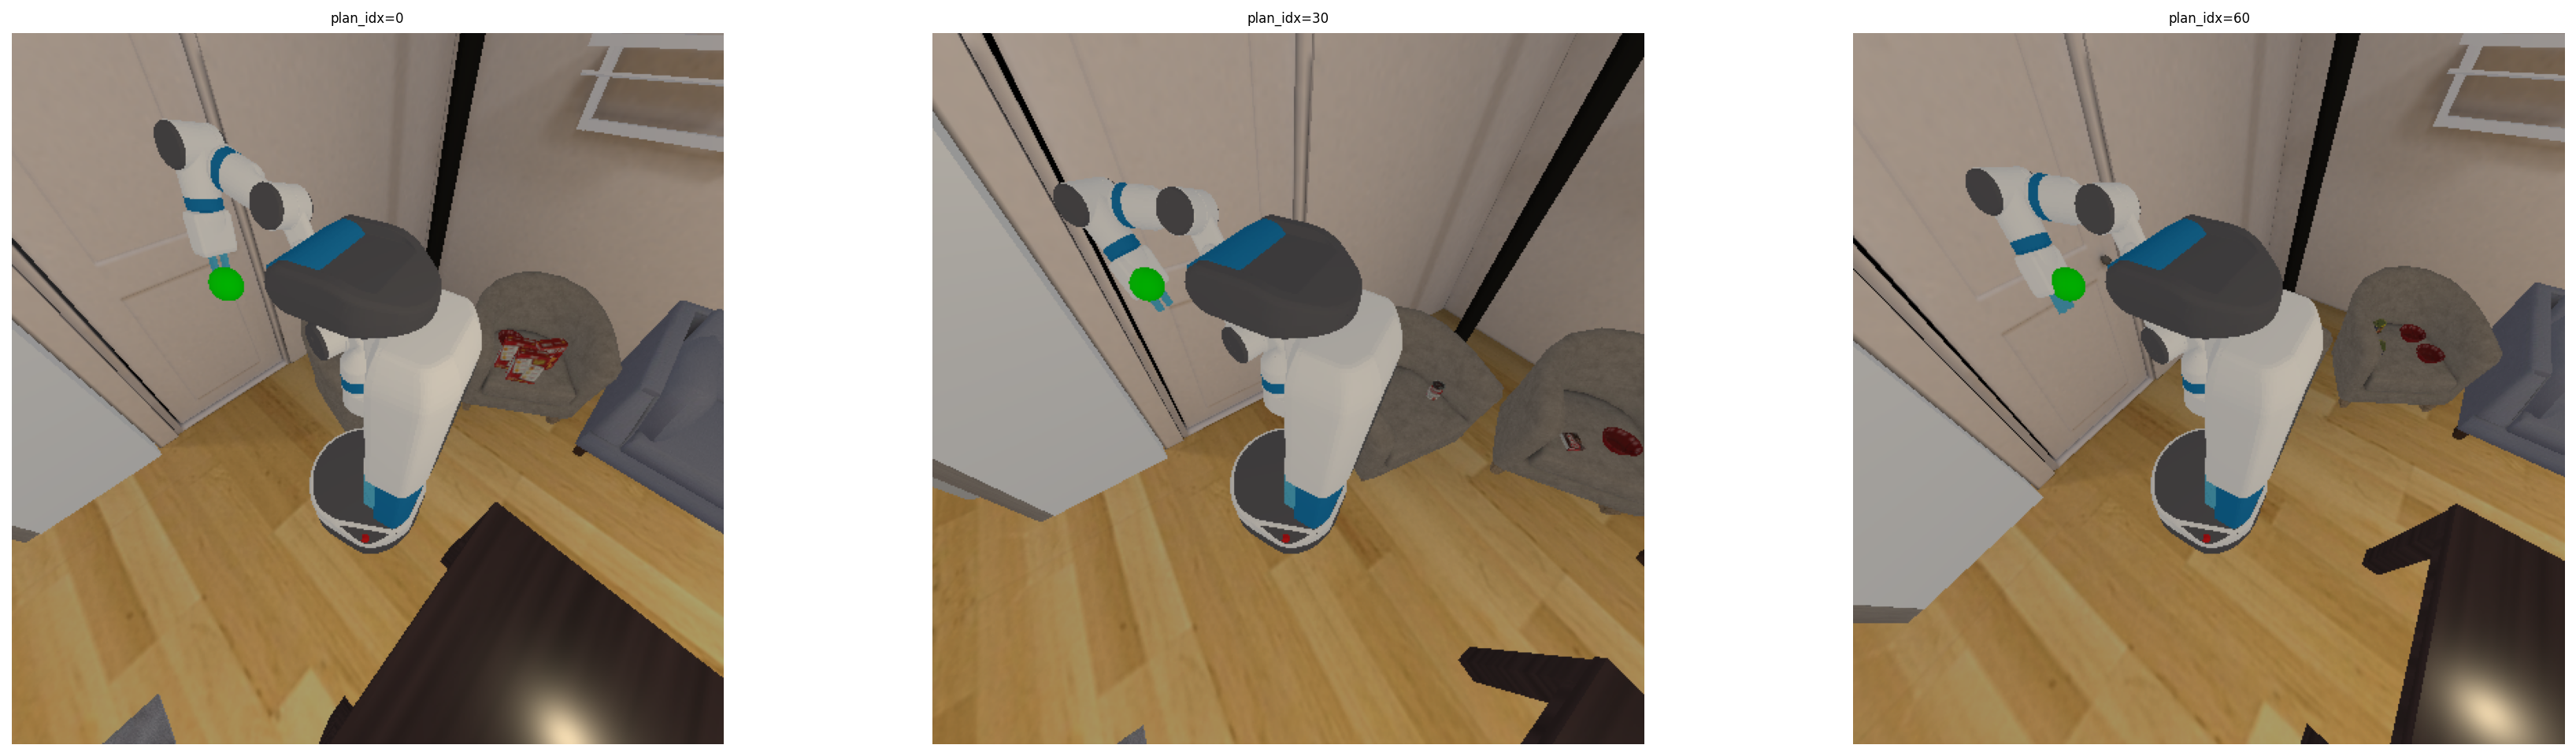

In [4]:
n = len(spawn_images)
ncols = min(3, n)
nrows = -(-n // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6.5 * nrows), dpi=150)
axes = np.atleast_1d(axes).flatten()
for ax, img, plan_idx in zip(axes, spawn_images, PLAN_INDICES):
  ax.imshow(img)
  ax.set_title(f'plan_idx={plan_idx}', fontsize=8)
  ax.axis('off')
for ax in axes[n:]:
  ax.axis('off')
plt.tight_layout()
plt.show()

## View goal images: base-standoff comparison (0.5m / 0.7m / 1.0m / 1.5m)

Rows are `BASE_STANDOFF_VALUES` (0.5m top, 1.5m bottom), columns are `PLAN_INDICES` (different
spawn/drawer instances within the one restricted scene). The magenta marker (the goal's
`handle_pos`) stays in the same world position down each column -- only the robot's base
distance and the arm's reach change across rows. Compare against `target_to_handle`/`ik_err` in
each panel's caption: `target_to_handle` is the base-to-handle standoff actually achieved (should
match the row's nominal value, modulo the small out-of-plane component the FK-peek's axis can
have), `ik_err` is how well the arm could still reach the (unchanged) handle target from that
base position -- a small, roughly-constant `ik_err` across rows means the arm has reach to spare;
a value that jumps up means that standoff may be pushing past what the arm can comfortably do.
Re-run this cell on its own (no need to re-render) to redisplay.

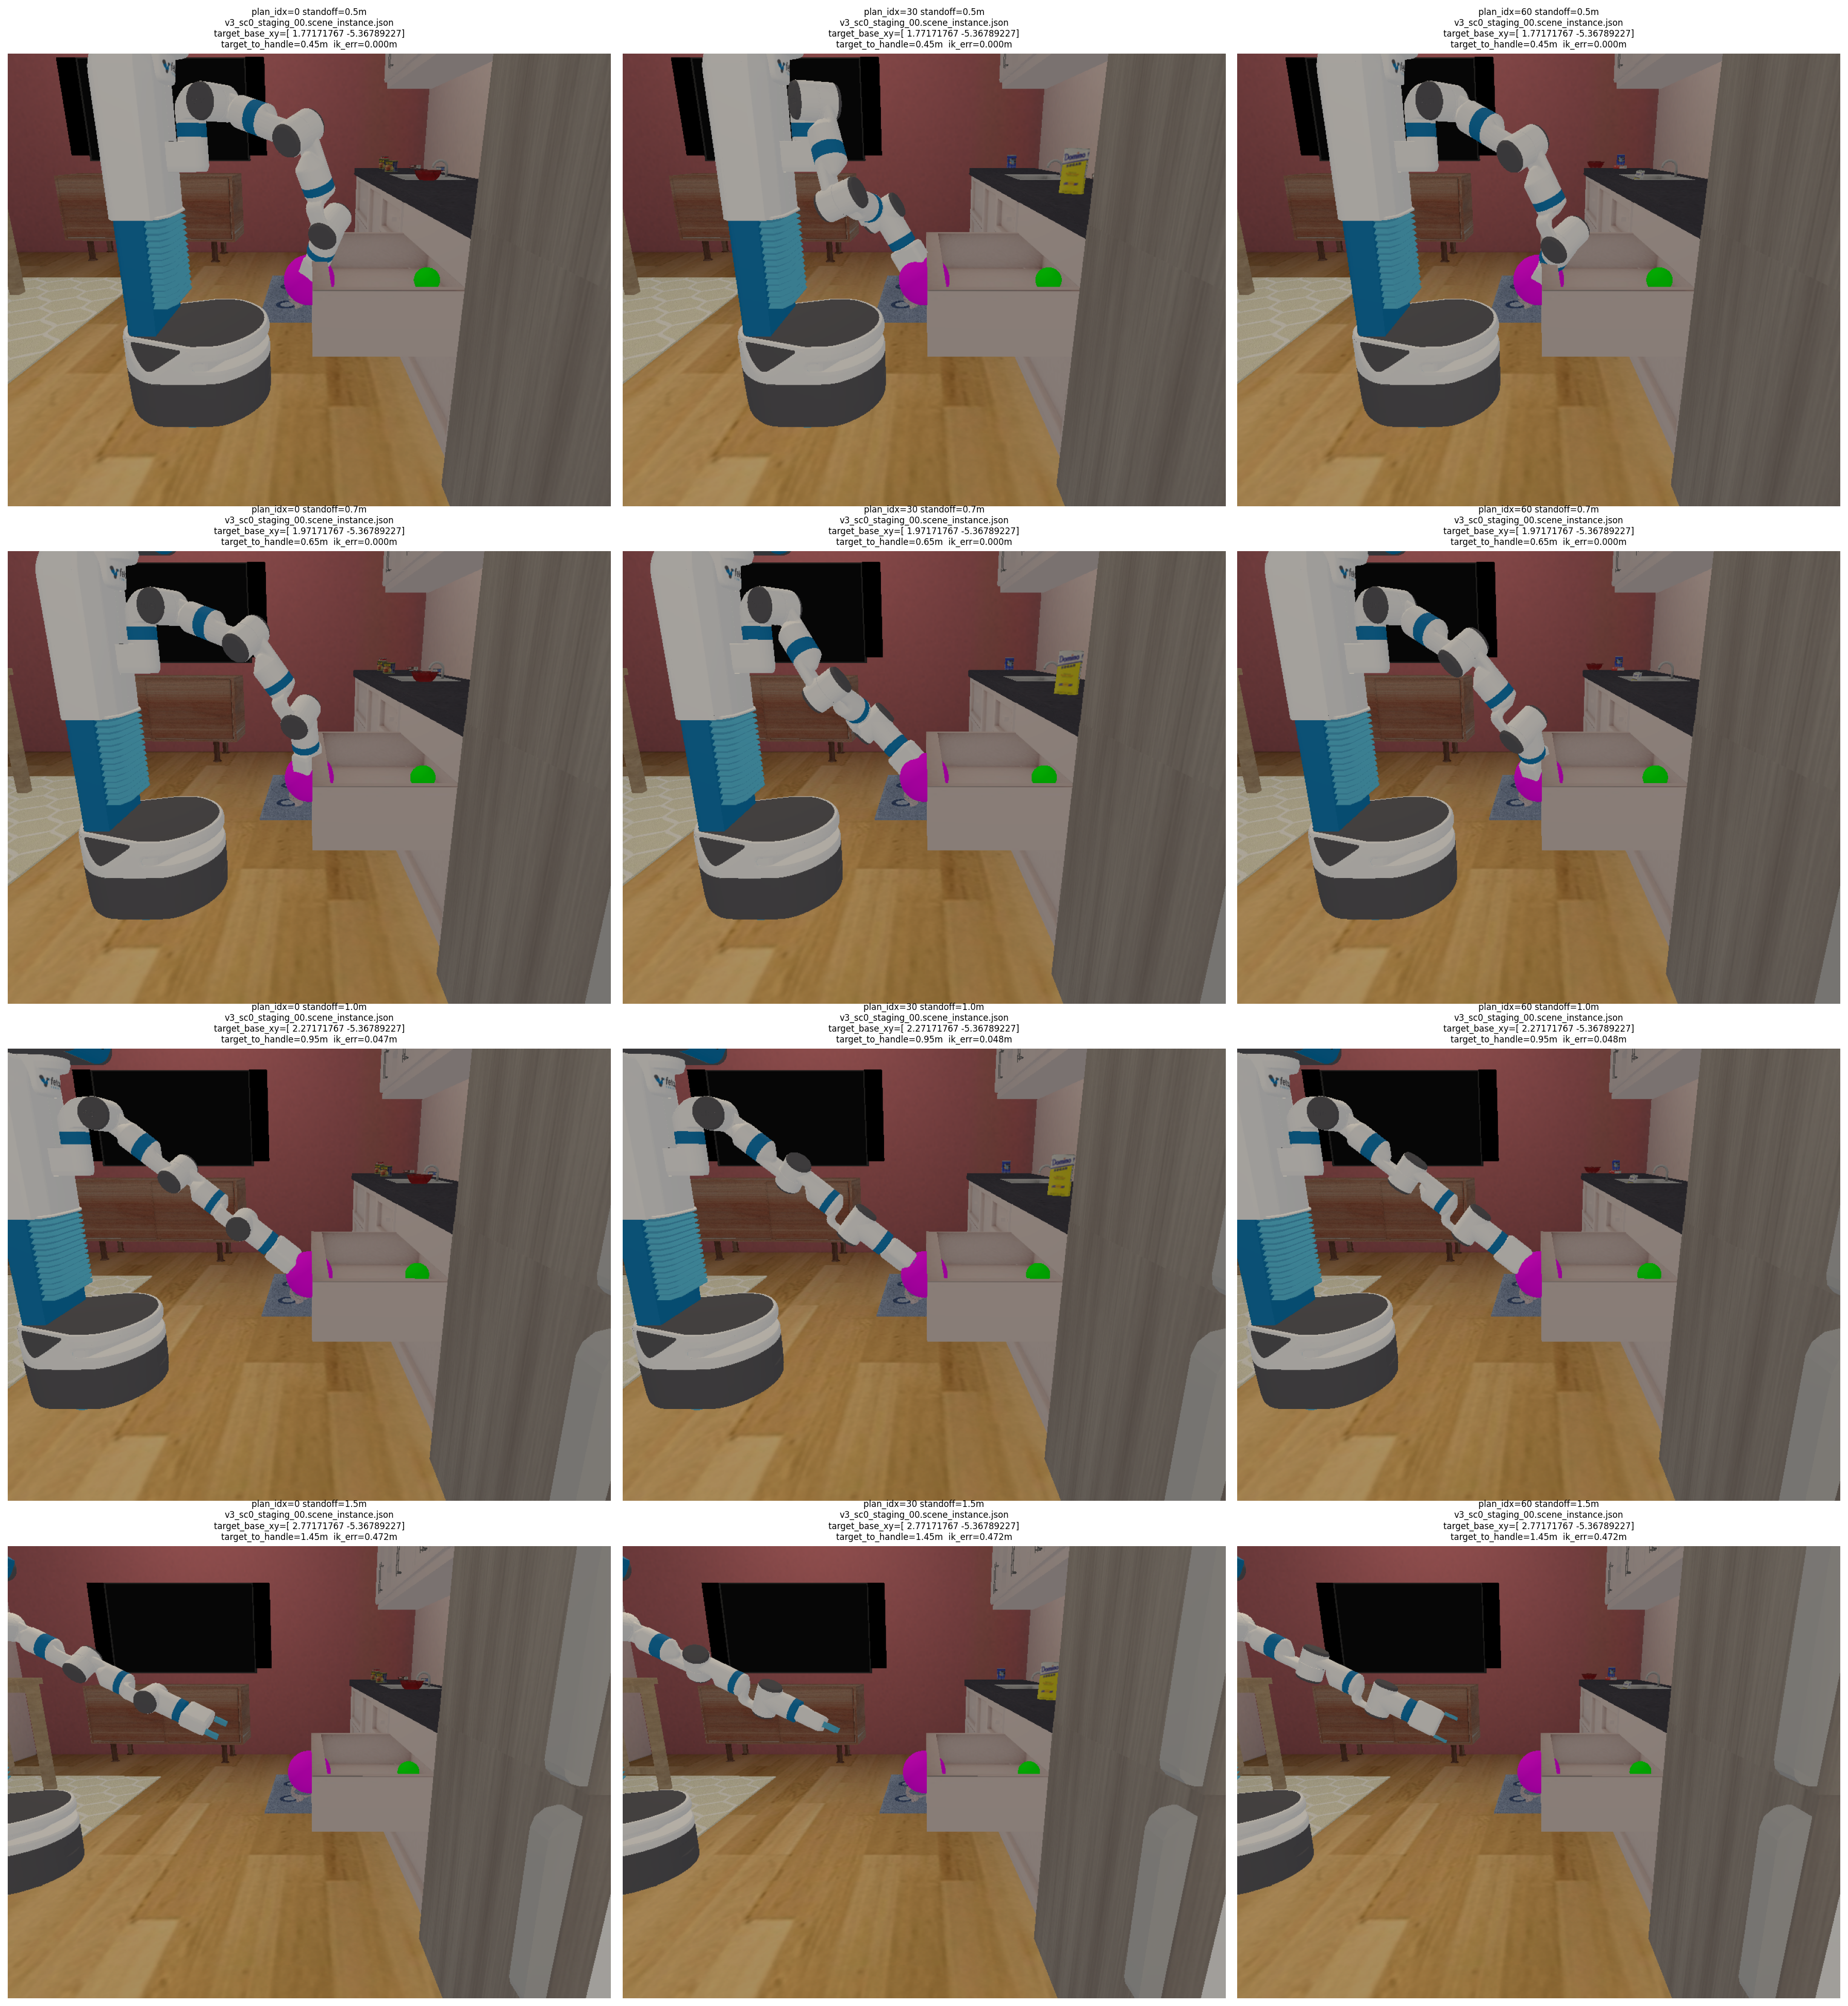

In [5]:
nrows = len(BASE_STANDOFF_VALUES)
ncols = len(PLAN_INDICES)
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6.5 * nrows), dpi=150)
axes = np.atleast_2d(axes)
for j in range(nrows):
  for i in range(ncols):
    ax = axes[j, i]
    ax.imshow(goal_images_grid[j][i])
    ax.set_title(captions_grid[j][i], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Is the gripper's goal position the same as the drawer handle in the open position?

**Almost, but not exactly -- and unaffected by the standoff sweep above.** The goal's
`handle_pos` (the first 3 dims of the 8-dim goal vector, base-relative) is the handle's position
at the drawer's open `target_qpos`, offset back **`GRIPPER_APPROACH_OFFSET_M` (0.05m by default)
toward *closed*** along the joint's own local motion axis -- see
`_open_handle_positions_custom`/`env_utils._open_subtask_open_handle_positions`'s docstring.
This offset is completely independent of `BASE_STANDOFF_M`/`base_target_xy`, so it's identical
across all three rows of the grid above -- the magenta marker never moves within a column.

So:
- The **drawer itself** really does reach the literal open `target_qpos` -- that part of the
  goal (goal dim 3, `target_qpos`) is unoffset.
- The **gripper's target position** is not flush with the handle at that configuration -- it's a
  "comfortable release point" ~5cm short of it (toward closed), matching the close-subtask
  goal's analogous "comfortable release point" just past the drawer's *closed* face. The
  per-example print above (`GRIPPER TARGET vs literal open-handle pos`) shows both world-frame
  points and the exact offset distance for each rendered example -- it should read ~`0.05m`
  whenever `GRIPPER_APPROACH_OFFSET_M` is left at its default (it can differ if the local axis is
  degenerate, e.g. already at a qpos limit).
- **What changes with the base standoff is only how far the arm has to reach**, not where the
  gripper's goal point is. The `arm IK final error` printed for each `(plan_idx, standoff)` pair
  is the practical readout for that: a small, stable error means the arm can still comfortably
  reach the (unmoved) handle target from that base position; a growing error at larger standoffs
  means the base is being pushed further back than the arm can actually cover, which would
  itself be a reason to prefer a smaller standoff even after resolving the close-vs-open
  distance-ordering concern that motivated this comparison.

The debug sphere in the images marks the **goal's** `handle_pos` (the offset point), not the
literal handle location.

## Close-subtask goal state, for direct comparison

Renders `maniskill_close_subtask_train`'s own goal state at its actual trained default
(`env_utils._CLOSE_SUBTASK_BASE_STANDOFF_M=1.0`, `env_utils._CLOSE_SUBTASK_APPROACH_OFFSET_M
=0.05` -- no local override, this calls the real
`env_utils._close_subtask_closed_handle_positions` training itself uses), using the same
`_build_overview_camera` framing as the open comparison above.

To make this a true apples-to-apples comparison rather than "some other close example," this
uses the **exact same physical drawer/articulation instance** as `PLAN_INDICES[0]`'s open
example above: `scripts/build_open_spawn_data.py` built `open`'s spawn data from `close`'s own
validated poses per matching subtask uid (`set_table-open-train-N-0` <-> `set_table-close-train
-N-0`, same `N`), so the same substitution (`'-open-' -> '-close-'`) recovers the matching close
task-plan entry here.

[render_goal_state] close comparison: uid=set_table-close-train-460-0 scene=v3_sc0_staging_00.scene_instance.json


[render_goal_state] close: target_base_xy=[ 1.83561766 -5.36789227] target_to_handle=0.95m (env_utils._CLOSE_SUBTASK_BASE_STANDOFF_M=1.0)
[render_goal_state] close: arm IK final error: 0.047m


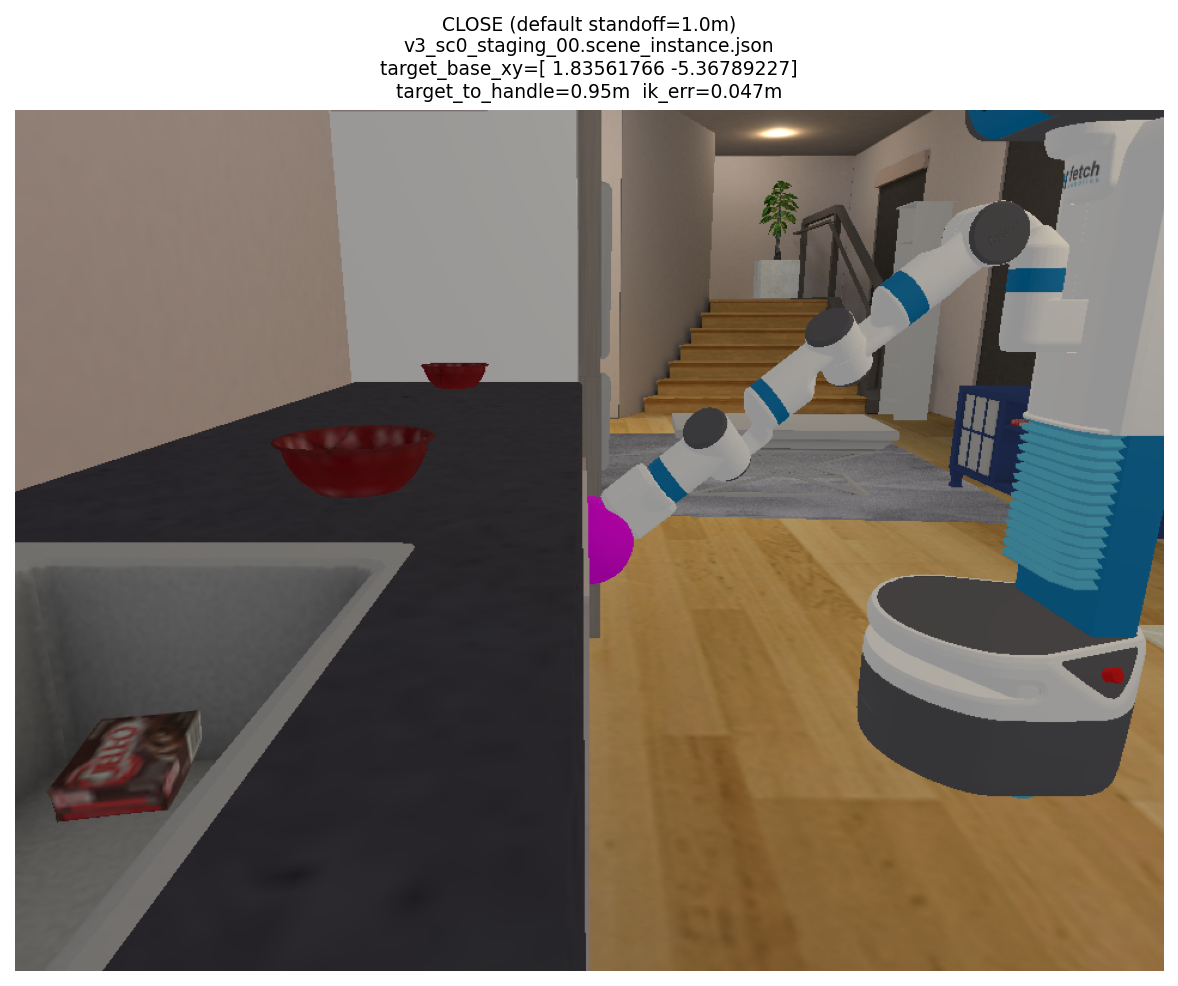

In [6]:
close_task_plan_fp, close_spawn_data_fp = env_utils._mshab_close_subtask_paths()
close_plan_data = env_utils._mshab_plan_data_from_file(close_task_plan_fp)

open_uid = plan_data.plans[PLAN_INDICES[0]].subtasks[0].uid
close_uid = open_uid.replace('-open-', '-close-')
close_plan = next(
    (tp for tp in close_plan_data.plans if tp.subtasks[0].uid == close_uid),
    None)
assert close_plan is not None, (
    f'no close task-plan entry found for uid={close_uid!r} (derived from '
    f'open uid={open_uid!r})')
print(f'[render_goal_state] close comparison: uid={close_uid} '
      f'scene={close_plan.build_config_name}')

close_gym_raw = env_utils._gymnasium.make(
    'CloseSubtaskTrain-v0',
    obs_mode='state_dict',
    control_mode='pd_joint_delta_pos',
    reward_mode='normalized_dense',
    render_mode='rgb_array',
    robot_uids='fetch',
    num_envs=1,
    task_plans=[close_plan],
    scene_builder_cls=close_plan_data.dataset,
    spawn_data_fp=close_spawn_data_fp,
    require_build_configs_repeated_equally_across_envs=False,
    sim_config=dict(
        gpu_memory_config=dict(
            temp_buffer_capacity=2**25,
            max_rigid_contact_count=2**24,
            found_lost_pairs_capacity=2**26,
            max_rigid_patch_count=2**22)))
close_obs_dict, _info = close_gym_raw.reset()
close_unwrapped = close_gym_raw.unwrapped
close_spawn_base_xy = env_utils._ms_to_numpy(close_unwrapped.agent.base_link.pose.p)[:2]
close_joint_idx = close_unwrapped.close_subtask.articulation_handle_active_joint_idx
close_env_idx = torch.zeros(1, dtype=torch.long, device=close_unwrapped.device)

# Real trained-default FK-peek -- no local override needed here, this IS
# what training actually uses (env_utils._CLOSE_SUBTASK_BASE_STANDOFF_M=1.0,
# env_utils._CLOSE_SUBTASK_APPROACH_OFFSET_M=0.05).
close_handle_target_p, close_base_target_xy = env_utils._close_subtask_closed_handle_positions(
    close_unwrapped, close_env_idx)
close_handle_world_p = close_handle_target_p[0]
close_base_target_xy = close_base_target_xy[0]

close_root_xy = env_utils._ms_to_numpy(close_unwrapped.agent.robot.root_pose.p)[:2]
close_handle_dist = float(np.linalg.norm(close_base_target_xy - close_handle_world_p[:2]))
print(f'[render_goal_state] close: target_base_xy={close_base_target_xy} '
      f'target_to_handle={close_handle_dist:.2f}m '
      f'(env_utils._CLOSE_SUBTASK_BASE_STANDOFF_M={env_utils._CLOSE_SUBTASK_BASE_STANDOFF_M})')

# --- Teleport into the goal configuration (mirrors the open loop above) ---
close_orig_art_qpos = close_unwrapped.articulation.qpos.clone()
close_peek_art_qpos = close_orig_art_qpos.clone()
close_peek_art_qpos[:, close_joint_idx] = close_unwrapped.target_qpos
close_unwrapped.articulation.set_qpos(close_peek_art_qpos)

close_peek_robot_qpos = close_unwrapped.agent.robot.get_qpos().clone()
close_handle_xy = close_handle_world_p[:2]
close_facing = float(np.arctan2(close_handle_xy[1] - close_base_target_xy[1],
                                close_handle_xy[0] - close_base_target_xy[0]))
close_qpos_xy = close_base_target_xy - close_root_xy
close_peek_robot_qpos[:, 0] = float(close_qpos_xy[0])
close_peek_robot_qpos[:, 1] = float(close_qpos_xy[1])
close_peek_robot_qpos[:, 2] = close_facing
# Gripper -> close's own goal aperture (fully OPEN, 0.10 total -- opposite
# of open-subtask's goal, see ManiskillCloseSubtaskTrain._GRIPPER_TARGET).
close_peek_robot_qpos[:, 13] = _FETCH_FINGER_MAX_OPEN_M
close_peek_robot_qpos[:, 14] = _FETCH_FINGER_MAX_OPEN_M
close_unwrapped.agent.robot.set_qpos(close_peek_robot_qpos)

close_solved_qpos, close_ik_err_m = _solve_arm_ik_fk(
    close_unwrapped, close_peek_robot_qpos, close_handle_world_p)
close_unwrapped.agent.robot.set_qpos(close_solved_qpos)
print(f'[render_goal_state] close: arm IK final error: {close_ik_err_m:.3f}m')

close_debug_marker = ms_actors.build_sphere(
    close_unwrapped.scene, radius=0.1, color=[1, 0, 1, 1],
    name='debug_handle_marker_close', body_type='kinematic',
    add_collision=False,
    initial_pose=env_utils._MsPose.create_from_pq(
        p=torch.as_tensor(close_handle_world_p[None], dtype=torch.float32)))

if close_unwrapped.gpu_sim_enabled:
  close_unwrapped.scene._gpu_apply_all()
  close_unwrapped.scene.px.gpu_update_articulation_kinematics()
  close_unwrapped.scene._gpu_fetch_all()

# side=-1.0: the default (+1.0) side was clipped by nearby room geometry at
# the closed-handle position (see _build_overview_camera's `side` param
# docstring) -- flip to the other lateral side for this render only.
close_overview_cam = _build_overview_camera(
    close_unwrapped, close_spawn_base_xy, close_base_target_xy, close_handle_world_p,
    side=-1.0)
close_unwrapped.scene.update_render()
close_overview_cam.capture()
close_overview_rgb = close_overview_cam.get_obs(
    rgb=True, depth=False, position=False, segmentation=False)['rgb']
close_goal_image = _frame(close_overview_rgb)
close_caption = (
    f'CLOSE (default standoff={env_utils._CLOSE_SUBTASK_BASE_STANDOFF_M}m)\n'
    f'{close_plan.build_config_name}\n'
    f'target_base_xy={close_base_target_xy}\n'
    f'target_to_handle={close_handle_dist:.2f}m  ik_err={close_ik_err_m:.3f}m')

close_gym_raw.close()

fig, ax = plt.subplots(figsize=(8, 6.5), dpi=150)
ax.imshow(close_goal_image)
ax.set_title(close_caption, fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.show()